# Eddy Flux

In [1]:
from smode_import import *

In [2]:
# load thermosalinograph data

TSG = xr.open_dataset('../S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
TSG = TSG.drop_duplicates(dim='time_bio')
TSG = TSG.drop_duplicates(dim='time')
flowrate_time_bio = TSG['flow_rate_lab_tsg'].interp(time=TSG['time_bio'], method='linear')
TSG['flowrate_time_bio'] = (TSG.chlorophyll_ACS.dims, flowrate_time_bio.values)
TSG

<xarray.Dataset> Size: 40MB
Dimensions:                              (time_bio: 32509, time: 147912,
                                          instrument: 1)
Coordinates:
  * time_bio                             (time_bio) datetime64[ns] 260kB 2023...
    latitude_bio                         (time_bio) float64 260kB ...
    longitude_bio                        (time_bio) float64 260kB ...
  * time                                 (time) datetime64[ns] 1MB 2023-04-07...
    latitude                             (time) float64 1MB ...
    longitude                            (time) float64 1MB ...
Dimensions without coordinates: instrument
Data variables: (12/47)
    TSG86                                (instrument) float64 8B ...
    TSG73                                (instrument) float64 8B ...
    SST62                                (instrument) float64 8B ...
    FLW19                                (instrument) float64 8B ...
    FLW20                                (instrument) float64 8B ...
    FLW09                                (instrument) float64 8B ...
    ...                                   ...
    beam_attenuation_657nm_ACS           (time_bio) float64 260kB ...
    chlorophyll_flourometer              (time_bio) float64 260kB ...
    particulate_organic_carbon_cstar     (time_bio) float64 260kB ...
    photosynthetically_active_radiation  (time_bio) float64 260kB ...
    CSTAR_QCflag                         (time_bio) float64 260kB ...
    flowrate_time_bio                    (time_bio) float64 260kB 2.844 ... 1...
Attributes: (12/52)
    DOI:                           10.5067/SMODE-RVTSG
    title:                         SMODE Shipboard bio-optical, meteorlogical...
    summary:                       Level-2 processed data from GPS, TSG and F...
    keywords:                      EARTH SCIENCE > OCEANS > OPTICS > ATTENUAT...
    keywords_vocabulary:           NASA Global Change Master Directory (GCMD)...
    conventions:                   CF-1.8, ACDD-1.3
    ...                            ...
    timetime_coverage_end:         2023-05-03T15:05:07Z
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    date_created:                  2023-04-13T00:00:00Z
    time_coverage_duration:        P25D20H10M57S
    comment:                       See readme.txt. Thermosalinograph Data are...

## POC concentration composite

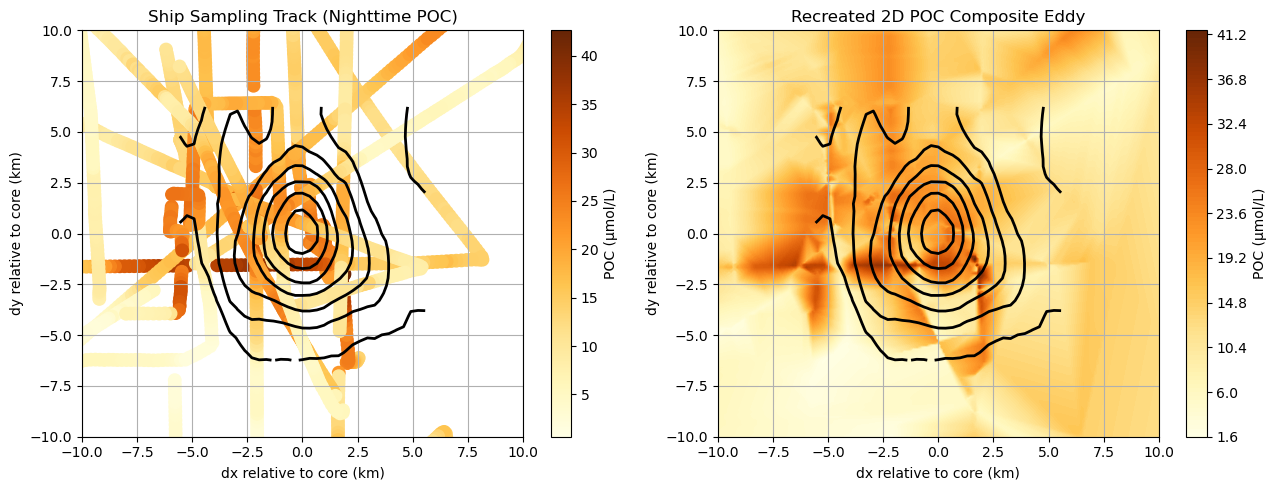

In [3]:
# POC composite

from scipy.interpolate import griddata
ds_interpolated = xr.open_dataset('../eddy_core_position.nc')

# get POC [μmol L-1] during the eddy time window
ACS_eddy_times = TSG['particulate_organic_carbon_acs'].sel(time_bio=slice('2023-04-18', '2023-04-23'))
upper_bound = 50  # Filter out outliers / biofouling spikes

# interpolate eddy core track onto ship sampling time
ds_interpolated_on_ACS = ds_interpolated.interp(time=ACS_eddy_times.time_bio, method='quadratic')

# calculate spatial offsets (dx, dy) in km relative to the eddy core
dlat = ds_interpolated_on_ACS.lat - ACS_eddy_times.latitude_bio
dlon = ds_interpolated_on_ACS.lon - ACS_eddy_times.longitude_bio

dy_km = dlat * 111320 / 1e3
dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_ACS.lat.values))) / 1e3
dist_from_core = np.sqrt(dx_km**2 + dy_km**2)

# keep night-time values only to remove photochemical quenching
def is_night(timestamp, delta=-7):  # UTC to PST
    return (timestamp.dt.hour < 9 - delta) | (timestamp.dt.hour >= 17 - delta)

idx = (
    (~np.isnan(ACS_eddy_times)) & # remove nans
    (~np.isnan(dy_km)) &
    (~np.isnan(dx_km)) &
    (ACS_eddy_times < upper_bound) & # remove excessive values
    (is_night(ACS_eddy_times.time_bio)) # keep nighttime values
)

dx_km = dx_km[idx].values 
dy_km = dy_km[idx].values
poc_umol_L = ACS_eddy_times.values[idx]  # [μmol / L]

# POC 2D composite

# uniform 2D grid [-10, 10] km relative to eddy core
grid_resolution = 200 # [m]
dist_max = 10
x_line = np.linspace(-dist_max, dist_max, grid_resolution)
y_line = np.linspace(-dist_max, dist_max, grid_resolution)
x_2d, y_2d = np.meshgrid(x_line, y_line)

# interpolate ship track POC values onto the 2D grid
poc_2d = griddata((dx_km, dy_km), poc_umol_L, (x_2d, y_2d), method='linear')

# calculate distance from core for every pixel on the 2D grid [km]
dist_2d = np.sqrt(x_2d**2 + y_2d**2)

# plot
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# overlay vorticity contours
composite_eddy = xr.open_dataset('../composite_eddy_centered.nc')
for axis in ax:
    composite_eddy.vor_eddy.plot.contour(levels=np.linspace(-2,2,16),colors='k',linewidths=2,ax=axis,zorder=101)

# Left: individual points along ship track
p0 = ax[0].scatter(dx_km, dy_km, c=poc_umol_L, s=80, cmap='YlOrBr')
ax[0].set_title("Ship Sampling Track (Nighttime POC)")
ax[0].set_xlabel("dx relative to core (km)")
ax[0].set_ylabel("dy relative to core (km)")
ax[0].set_xlim(-dist_max, dist_max)
ax[0].set_ylim(-dist_max, dist_max)
ax[0].grid(True)
plt.colorbar(p0, ax=ax[0], label="POC (μmol/L)")

# Right: interpolated 2D POC composite
p1 = ax[1].contourf(x_2d, y_2d, poc_2d, levels=100, cmap='YlOrBr')
ax[1].set_title("Recreated 2D POC Composite Eddy")
ax[1].set_xlabel("dx relative to core (km)")
ax[1].set_ylabel("dy relative to core (km)")
ax[1].set_xlim(-dist_max, dist_max)
ax[1].set_ylim(-dist_max, dist_max)
ax[1].grid(True)
plt.colorbar(p1, ax=ax[1], label="POC (μmol/L)")

plt.tight_layout()
plt.show()

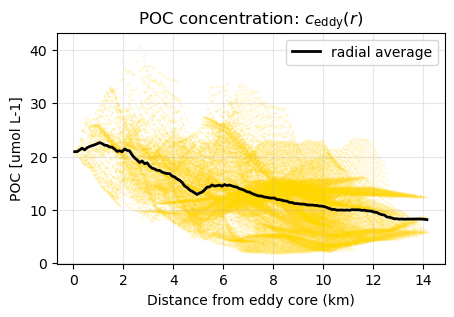

In [4]:
# POC as a function from dist_from_core (from 0 to 10 km)

dist_radial = np.sqrt(x_2d**2 + y_2d**2)

bin_width = 0.1 # [km]
r_bins = np.arange(0, np.max(dist_radial) + bin_width, bin_width)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2.0 # for plotting

# initialize
poc_radial_mean = np.zeros(len(r_centers))
poc_radial_std = np.zeros(len(r_centers))

for i in range(len(r_centers)):
    bin_mask = (dist_2d >= r_bins[i]) & (dist_2d < r_bins[i+1]) & (~np.isnan(poc_2d))
    
    if np.any(bin_mask):
        poc_radial_mean[i] = np.mean(poc_2d[bin_mask])
        poc_radial_std[i] = np.std(poc_2d[bin_mask])
    else:
        poc_radial_mean[i] = np.nan
        poc_radial_std[i] = np.nan

# plot
plt.figure(figsize=(5,3))
plt.scatter(dist_radial, poc_2d.flatten(), s=1, c='gold', alpha=0.1)
plt.plot(r_centers, poc_radial_mean, c='k', lw=2, label='radial average')

plt.legend()
plt.grid(alpha=0.3)
plt.xlabel('Distance from eddy core (km)')
plt.ylabel('POC [umol L-1]')
plt.title(r'POC concentration: $c_{\text{eddy}}(r)$')
plt.show();

## Submesoscale Eddy POC Inventory

To total POC inventory of our submesoscale eddy is:
$$
M_{\text{eddy}} = MLD \times 2\pi \int_{0}^{R_{\text{eddy}}} c_{\text{eddy}}(r)~rdr
$$

where $c_{\text{eddy}}$ is the measured POC concentration averaged from TSG, $R_{\text{eddy}}$ is the eddy's radius ($5~km$), MLD is the mixed-layer depth ($25~m$).

Note that any variable with subscript $_{\text{eddy}}$ refers to our own submesoscale eddy.

In [6]:
from scipy.integrate import trapezoid

# parameters
MW_C = 12.011   # Molecular weight of carbon (mg/mmol or g/mol)
MLD = 25      # Mixed-layer depth (m)
R_eddy = 5000 # Eddy radius (m)

# keep data within 5 km
r_m = r_centers * 1000.0 # km to m
mask = ~np.isnan(poc_radial_mean) & ~np.isnan(poc_radial_std) & (r_m <= R_eddy)

r_valid = r_m[mask]
poc_mean_valid = poc_radial_mean[mask] # mmol m-3
poc_std_valid = poc_radial_std[mask]   # mmol m-3

# integral
poc_integration_mean = trapezoid(poc_mean_valid * r_valid, x=r_valid) # mmol m-1
M_eddy_mmol = MLD * 2*np.pi * poc_integration_mean # [mmol C]

# conversion mol to grams
M_eddy_g = M_eddy_mmol * MW_C / 1000.0   # [g C]
M_eddy_Gg = M_eddy_mmol * MW_C/ 1e12 # [Gg C]

# std propagation (trapezoidal rule)
weights = np.gradient(r_valid)
std_integration = np.sqrt(np.sum((weights * r_valid * poc_std_valid)**2))

M_eddy_std_mmol = MLD * 2*np.pi * std_integration # [mmol C]
M_eddy_std_Gg = (M_eddy_std_mmol * MW_C) / 1e12       # [Gg C]

# volumetric concentration (we divide by eddy volume)
V_eddy = np.pi * (R_eddy**2) * MLD # m^3
C_bar_eddy = M_eddy_mmol / V_eddy  # [mmol m^-3]
C_bar_eddy_std = M_eddy_std_mmol / V_eddy  # [mmol m^-3]

#print(f"Total POC Inventory: {C_eddy_mmol:.2e} +/- {C_eddy_std_mmol:.2e} mmol C")
print(f"Eddy POC Inventory: {M_eddy_Gg:.4f} ± {M_eddy_std_Gg:.4f} Gg C")
print(f"Eddy POC Concentration: {C_bar_eddy:.2f} ± {C_bar_eddy_std:.2f} mmol m-3")

Eddy POC Inventory: 0.4051 ± 0.0192 Gg C
Eddy POC Concentration: 17.18 ± 0.81 mmol m-3


## POC Eddy Export Flux

The lateral eddy export flux of POC is given by:
$$
F' = u_{\text{eddy}} \times \bar{C}' \times \hat{f}
$$

* $u_{\text{eddy}}$ is the zonal velocity inferred from our submesoscale eddy position from Dopplerscatt observations
* $C'$ is the POC concentration anomaly ($\text{mmol m}^{-3}$) relative to the ambient background using satellite imagery of surface POC
* $\hat{f}$ is spatial fraction ($0 \le \hat{f} \le 1$) of eddy occupation along the cloud-free 124$\degree$W line, from 33 to 39$\degree$N


### Zonal Velocity (u_eddy)
We assume our eddy's u is average, not in paper's limitations

In [7]:
u_eddy = 0.05 # m s-1

### Eddy POC Concentration $(\bar{C}')$

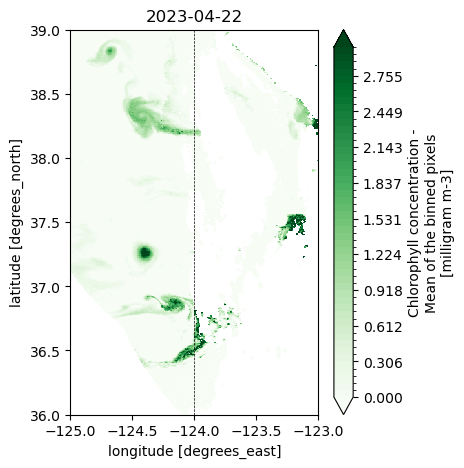

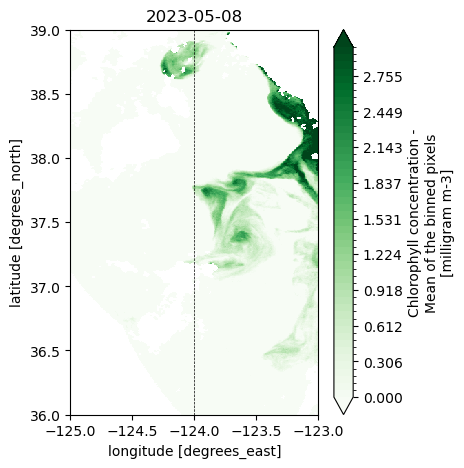

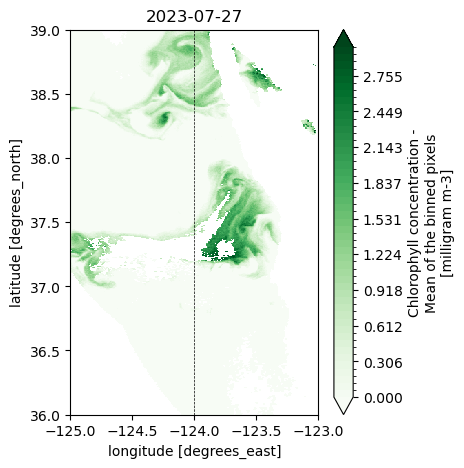

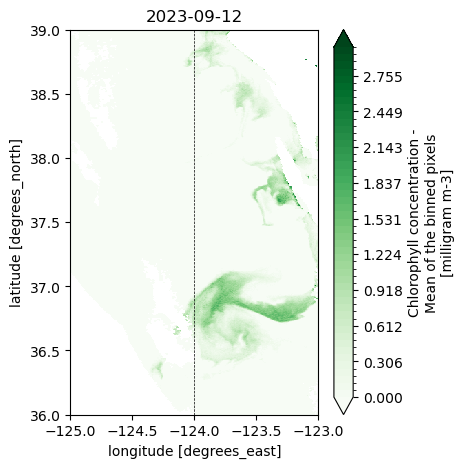

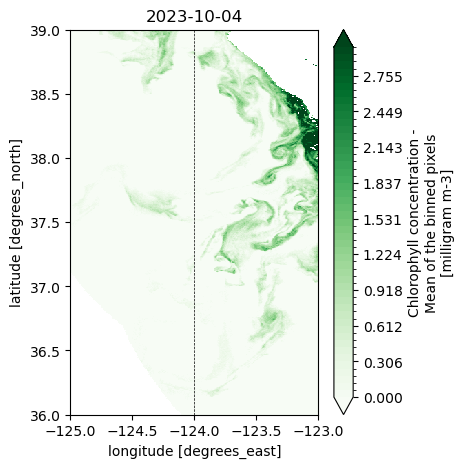

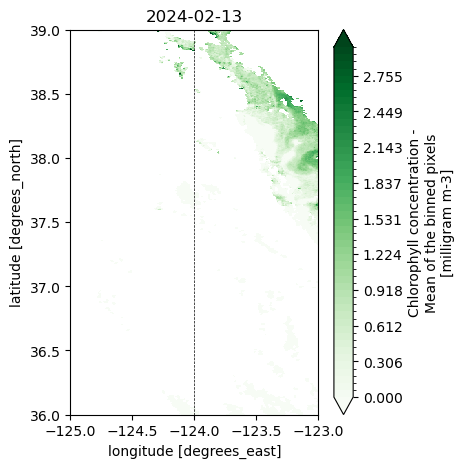

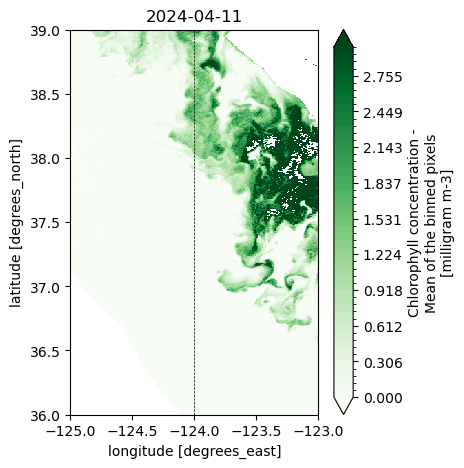

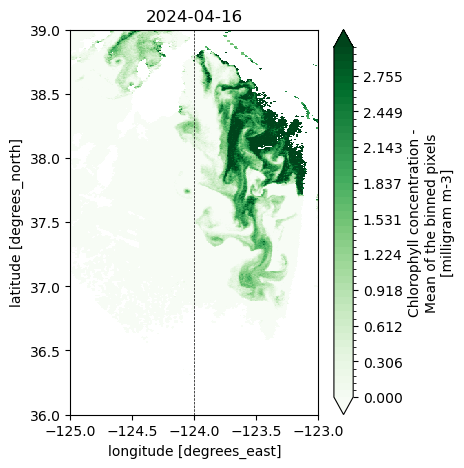

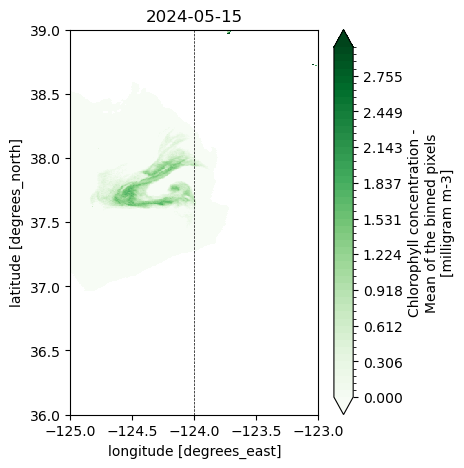

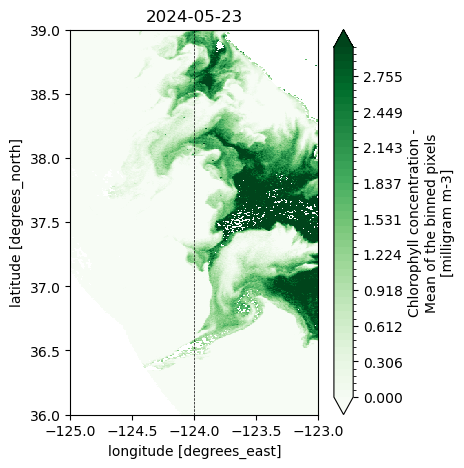

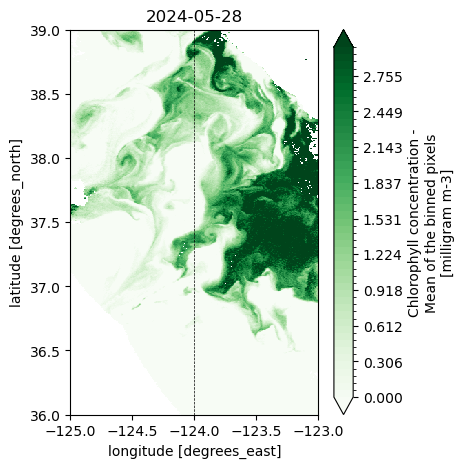

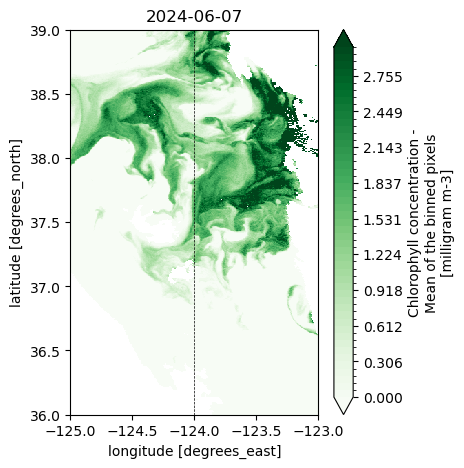

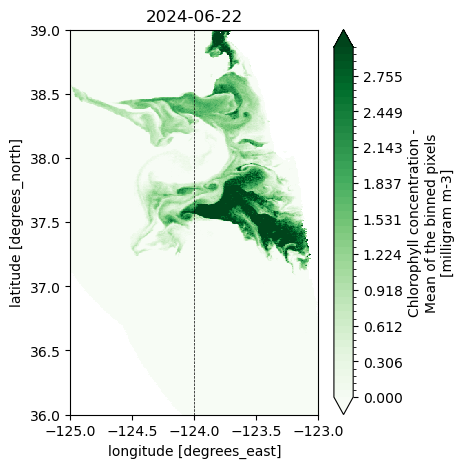

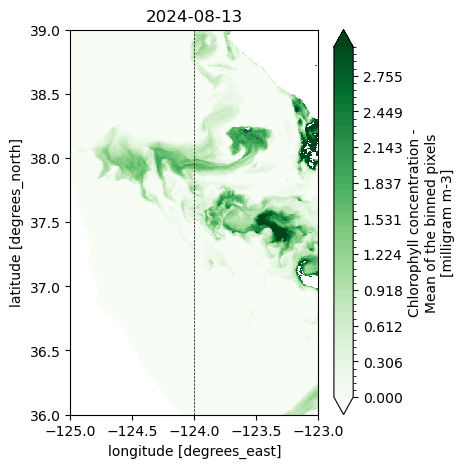

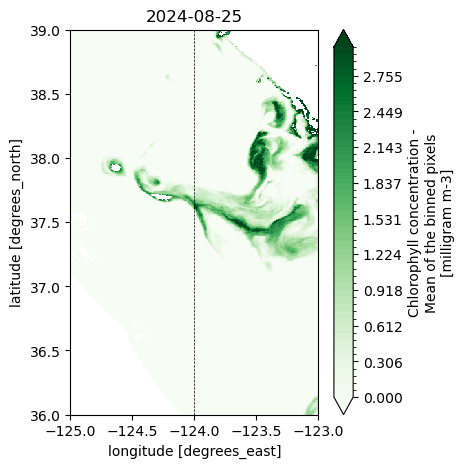

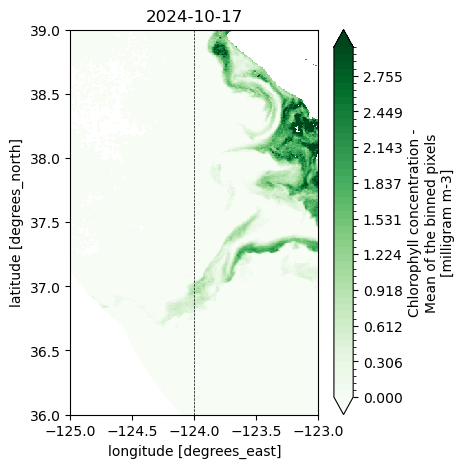

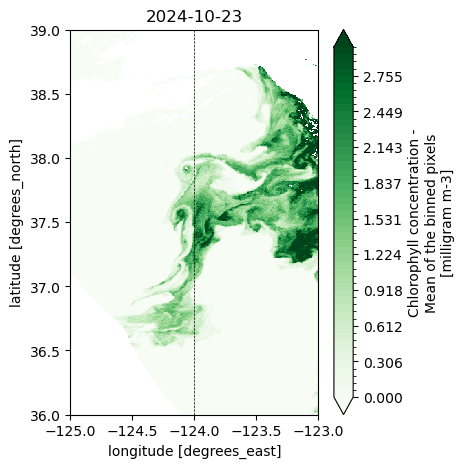

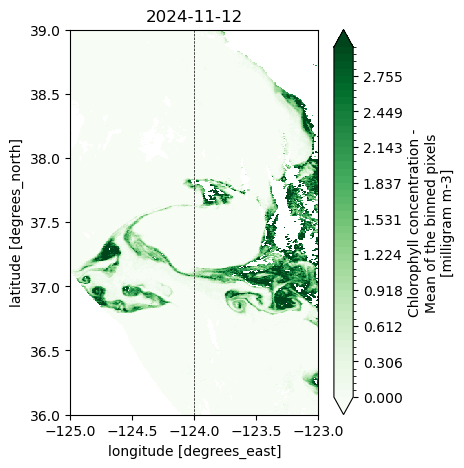

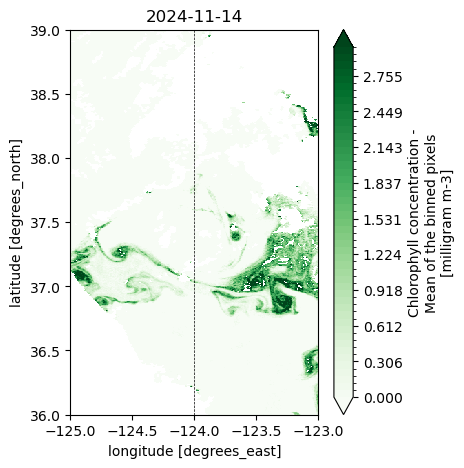

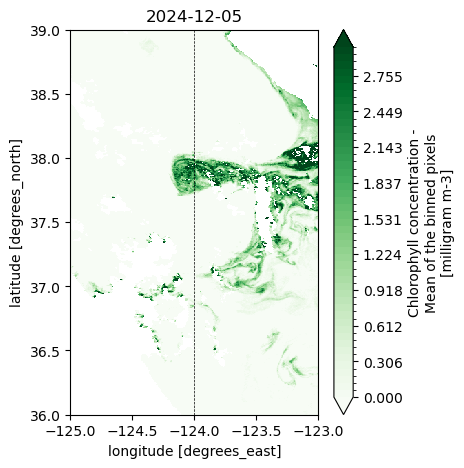

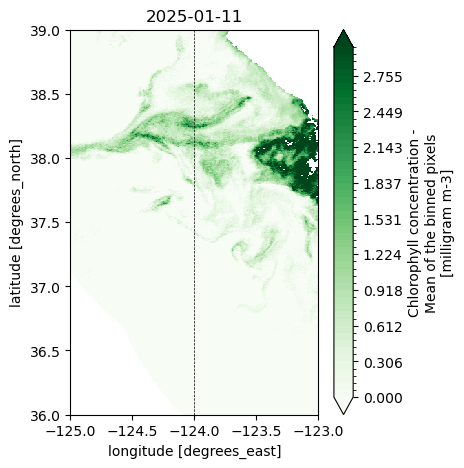

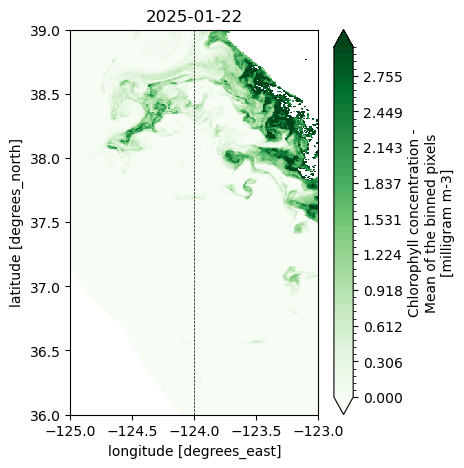

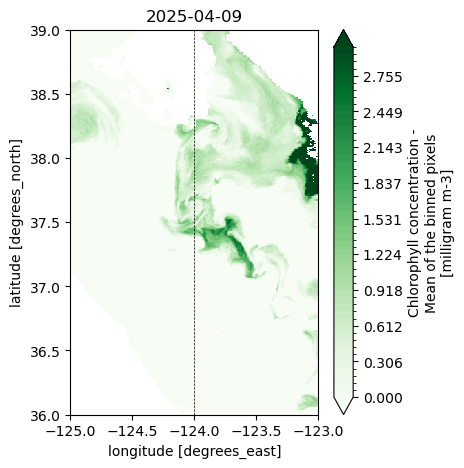

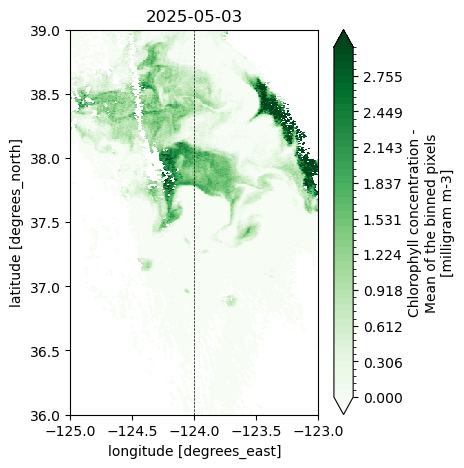

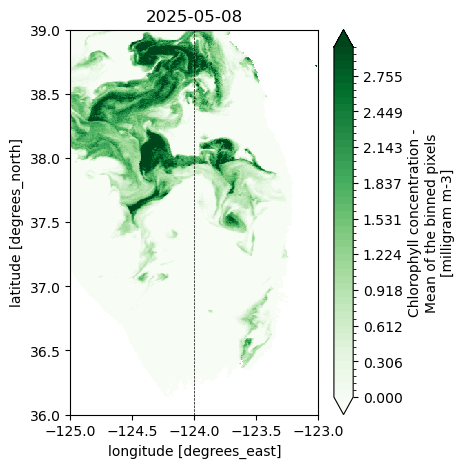

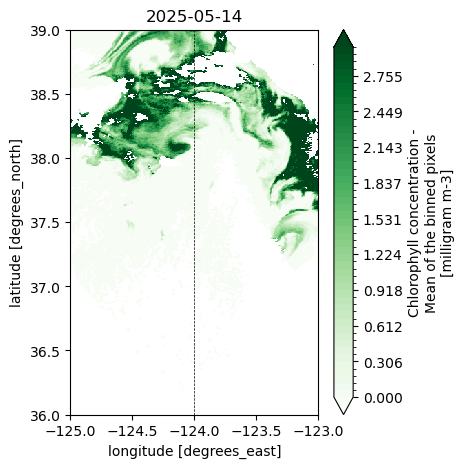

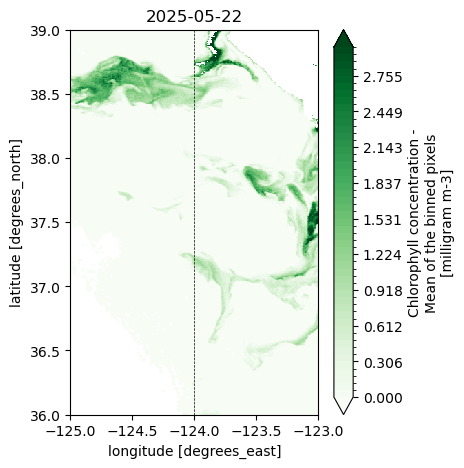

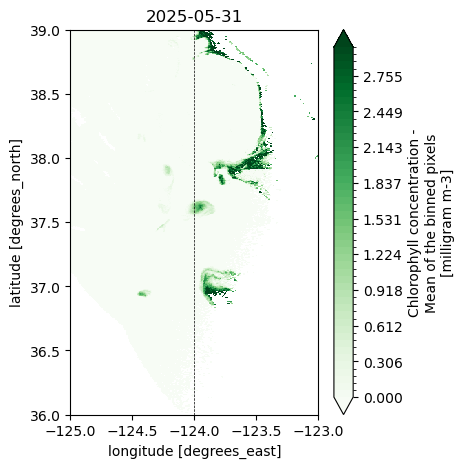

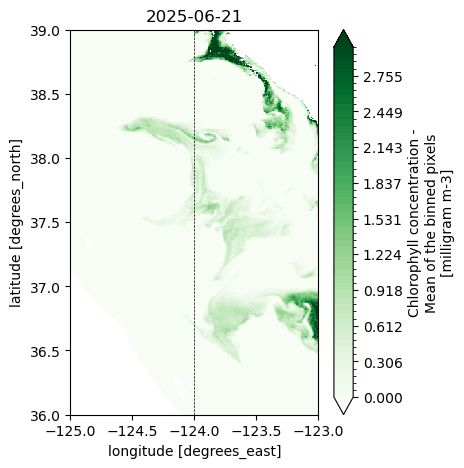

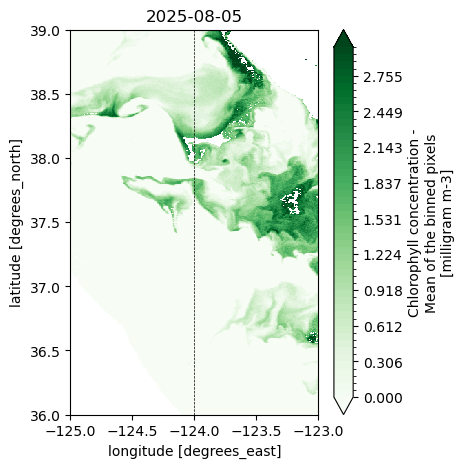

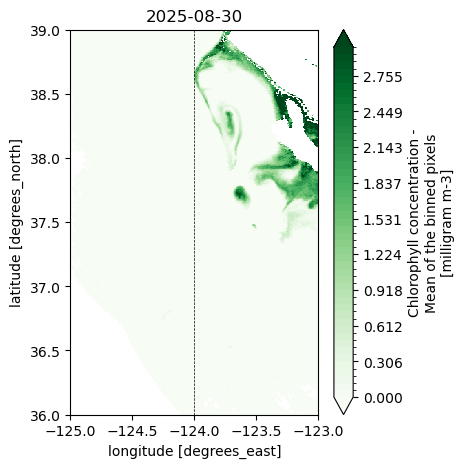

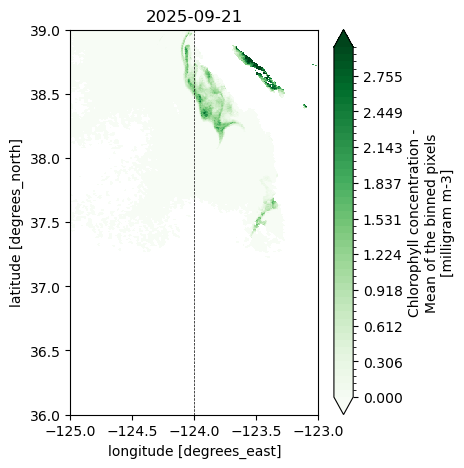

In [167]:
# 1. First we look through all the snapshots to find the exact coordinates of the submesoscale eddies
from glob import glob
MW_C = 12.011

OLCI_files = sorted(glob('../olci_300m_downloads/*'))

for file in OLCI_files:
    chl_300m = xr.open_dataset(file)['CHL']

    chl_300m_log = np.log(chl_300m)

    # Loisel et al. / Stramski et al. conversion algorithm
    poc_mg_m3 = 308.28 * (chl_300m ** 0.56) # to POC mass concentration [mg/m3]
    poc_mmol_m3 = poc_mg_m3 / MW_C # to molar concentration [mmol C / m3]

    time_str = str(chl_300m.time.values)[2:12]

    fig, ax = plt.subplots(1,1,figsize=(4,5))

    chl_300m_log.plot(levels=np.linspace(0,3,50), extend='both', ax=ax, cmap='Greens') # log chl
    #poc_mg_m3.plot(ax=ax[1], cmap='Oranges') # mass concentration
    #poc_mmol_m3.plot(ax=ax[1], cmap='YlOrBr',vmin=0,vmax=400,cbar_kwargs={'label': r'POC [mmol C m$^{-3}$]'}) # mol concentration
    #for axis in ax:
    ax.axvline(-124,color='k',linestyle='--',lw=0.5)
    ax.set_title(time_str)
    
    plt.xlim(-125, -123)
    plt.ylim(36,39)
    plt.show();
    

#C_bar_prime = 

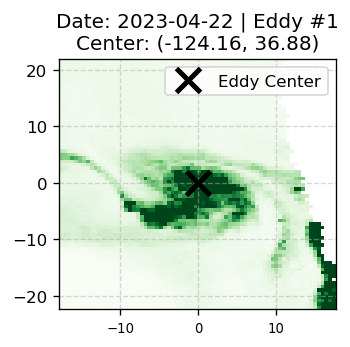

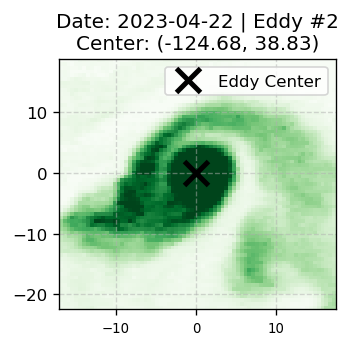

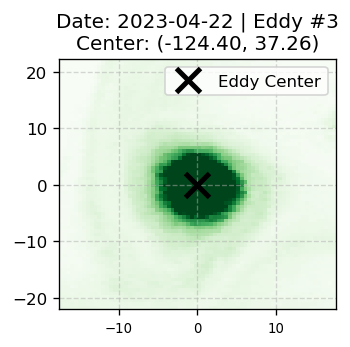

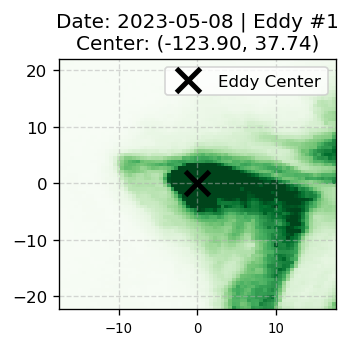

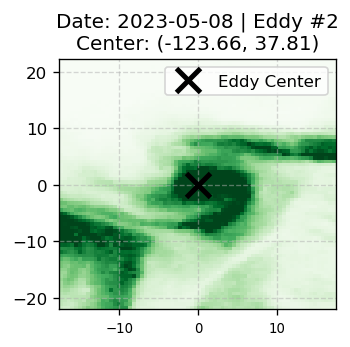

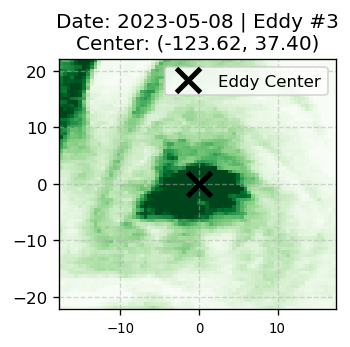

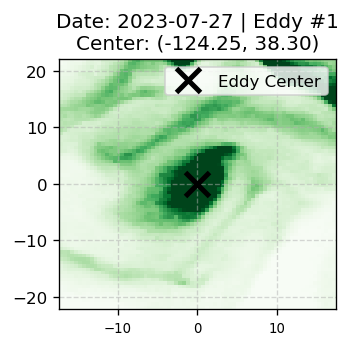

No coordinates listed for 2023-09-12, skipping...


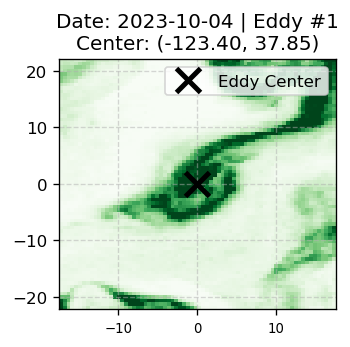

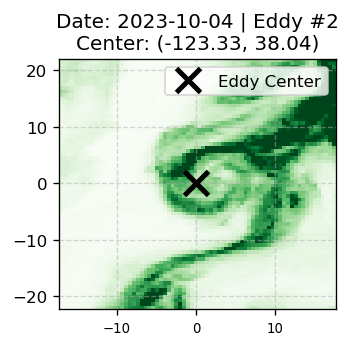

No coordinates listed for 2024-02-13, skipping...
No coordinates listed for 2024-04-11, skipping...


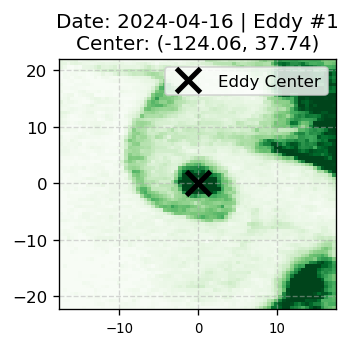

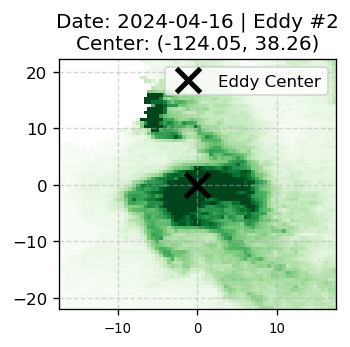

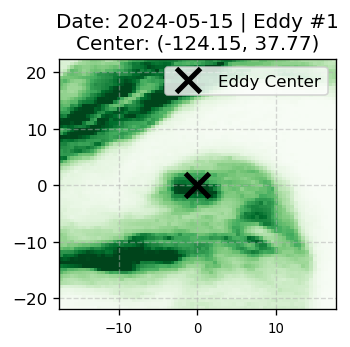

No coordinates listed for 2024-05-23, skipping...


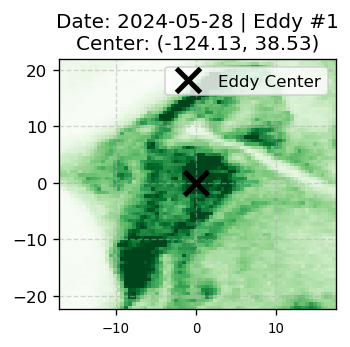

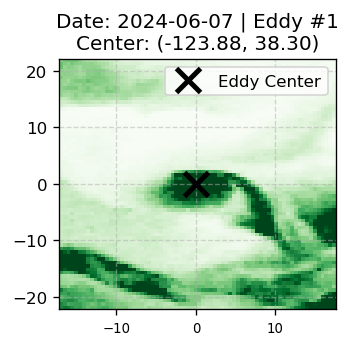

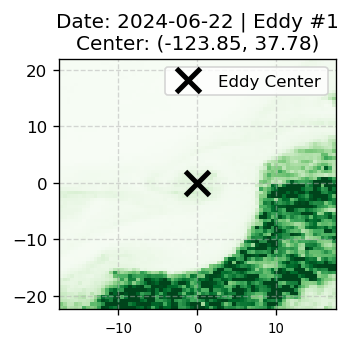

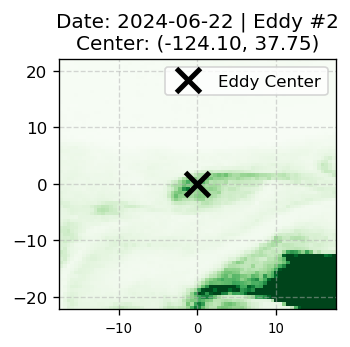

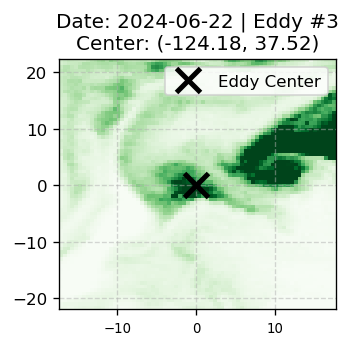

No coordinates listed for 2024-08-13, skipping...


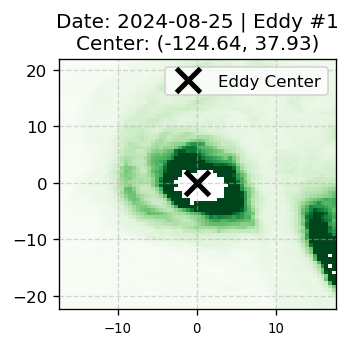

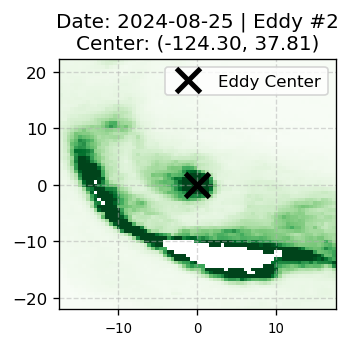

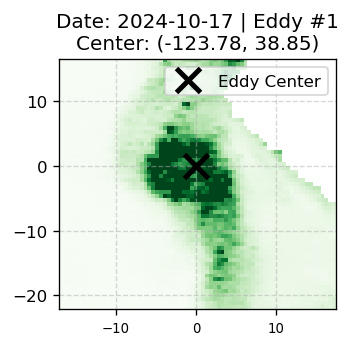

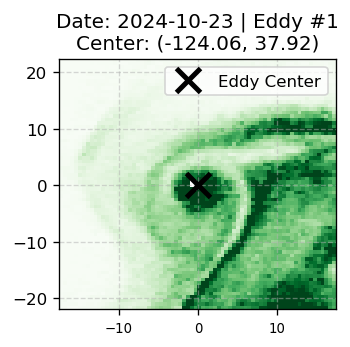

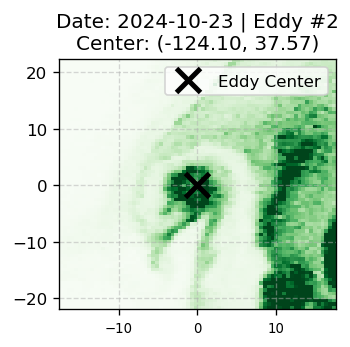

No coordinates listed for 2024-11-12, skipping...


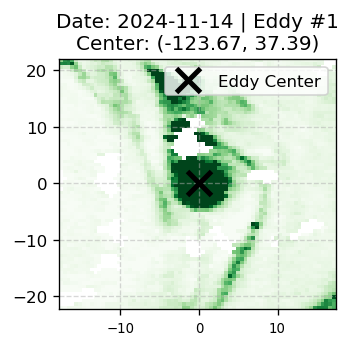

No coordinates listed for 2024-12-05, skipping...


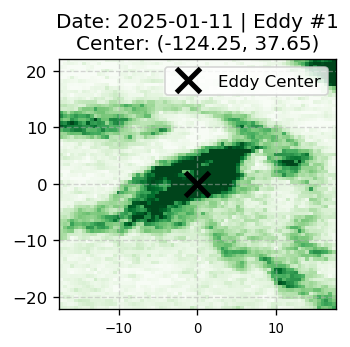

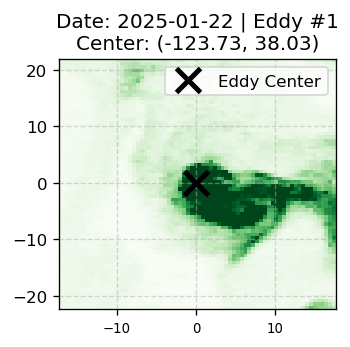

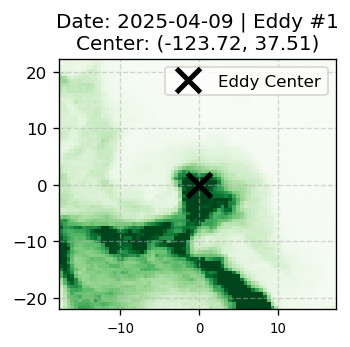

No coordinates listed for 2025-05-03, skipping...


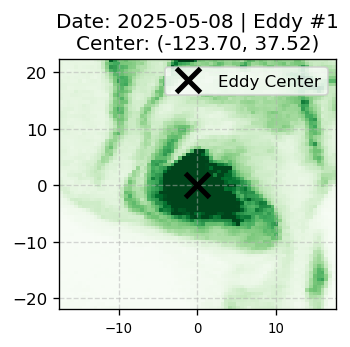

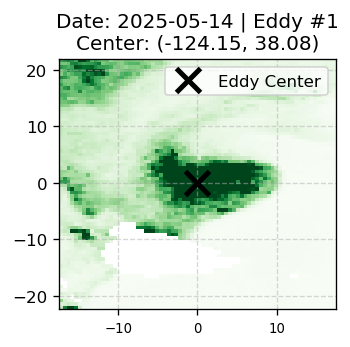

No coordinates listed for 2025-05-22, skipping...


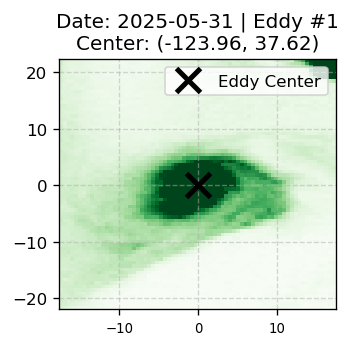

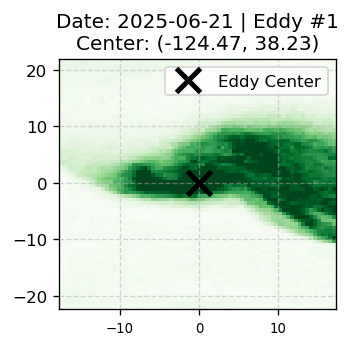

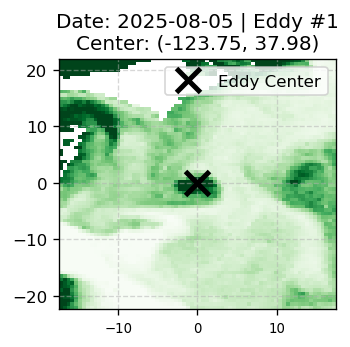

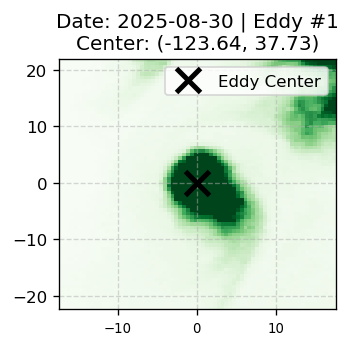

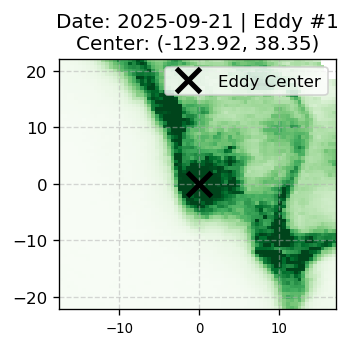

In [171]:
# 2. We verify they lat/lon coordinates by zooming in on each individual submesoscale eddy
import ast
import os

# load excel sheet
excel_path = "../count-submesoscale-eddies.xlsx"
df = pd.read_excel(excel_path)
df.columns = ['Date', 'Count', 'Coord1', 'Coord2', 'Coord3'] + list(df.columns[5:])

# helper to parse "(Lon,Lat)"
def parse_coord(coord_str):
    if pd.isna(coord_str) or not isinstance(coord_str, str):
        return None
    try:
        lon, lat = ast.literal_eval(coord_str.strip())
        return float(lon), float(lat)
    except:
        return None # this is for empty coords

olci_dir = "../olci_300m_downloads"

# loop through each submesoscale eddy
for idx, row in df.iterrows():
    # convert date string to YYYY-MM-DD to find file
    date_dt = pd.to_datetime(row['Date'])
    try:
        date_str = date_dt.strftime('%Y-%m-%d')
    except:
        continue
    nc_file = os.path.join(olci_dir, f"OLCI_300m_CHL_{date_str}.nc")
        
    # get (Lon,Lat)
    coords = [parse_coord(row['Coord1']), parse_coord(row['Coord2']), parse_coord(row['Coord3'])]
    coords = [c for c in coords if c is not None]
    
    if not coords:
        print(f"No coordinates listed for {date_str}, skipping...")
        continue
        
    # Open NetCDF dataset
    ds = xr.open_dataset(nc_file)
    chl = ds['CHL']
    
    # Plot each coordinate individually
    for ed_idx, (lon_center, lat_center) in enumerate(coords, 1):
        # Slice +/- 0.5 degrees around center
        delta = 0.2
        chl_crop = chl.sel(
            latitude=slice(lat_center - delta, lat_center + delta),
            longitude=slice(lon_center - delta, lon_center + delta)
        )

        # Extract 2D coordinate arrays
        lons = chl_crop.longitude.values
        lats = chl_crop.latitude.values
        
        # Convert lat/lon grid into relative kilometer offsets dx, dy from center (0,0)
        dy = (lats - lat_center) * 111.0  # km north/south
        dx = (lons - lon_center) * 111.0 * np.cos(np.radians(lat_center))  # km east/west

        plot_type = 'relative' # 'latlon'

        # === PLOT SECTION ===
        fig, ax = plt.subplots(figsize=(3, 3), dpi=120)

        # plot OLCI chl
        if plot_type=='relative':
            # plot in relative kilometer space (dx, dy)
            mesh = ax.pcolormesh(dx, dy, np.squeeze(chl_crop.values), cmap='Greens', shading='nearest',
                                 vmin=np.nanpercentile(chl_crop.values, 5),
                                 vmax=np.nanpercentile(chl_crop.values, 95)
            )

            # draw "X" at (0,0)
            ax.plot(0, 0, 'kx', markersize=14, markeredgewidth=3, label='Eddy Center')
            
        elif plot_type=='latlon':
            p = chl_crop.plot(ax=ax, cmap='Greens', robust=True, cbar_kwargs={'label': r'Chlorophyll-a [mg m$^{-3}$]'})
        
            # draw "X" on eddy center
            ax.plot(lon_center, lat_center, 'kx', markersize=14, markeredgewidth=3, label='Eddy Center')
        
        ax.set_title(f"Date: {date_str} | Eddy #{ed_idx}\nCenter: ({lon_center:.2f}, {lat_center:.2f})")
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right')
        ax.set_xlabel('')
        ax.set_ylabel('')
        plt.xticks(fontsize=8)
        plt.tight_layout()
        plt.show()
        
    ds.close()

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


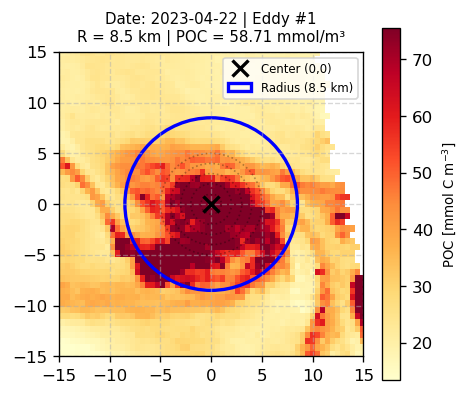

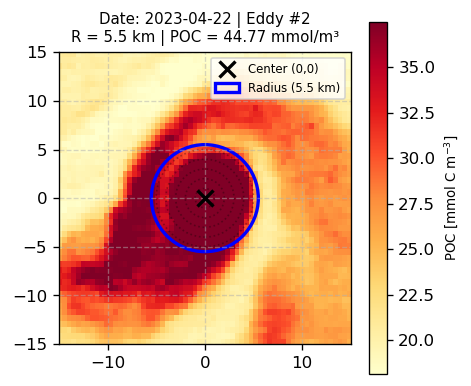

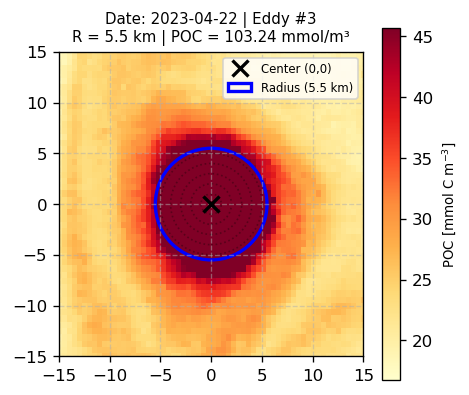

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


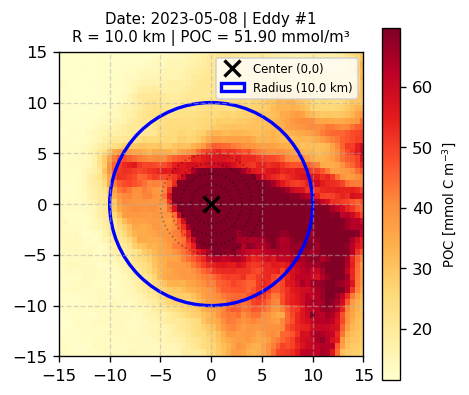

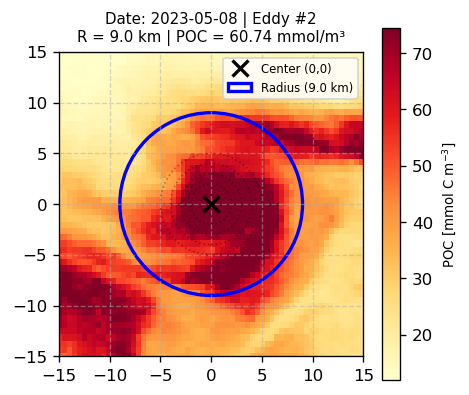

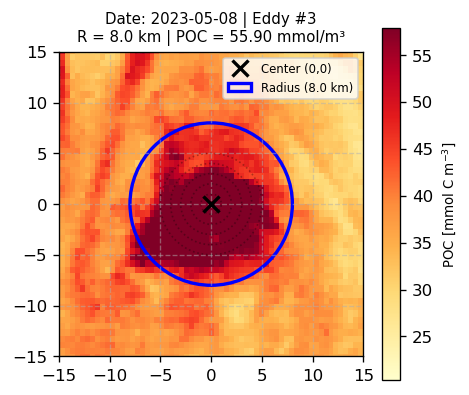

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


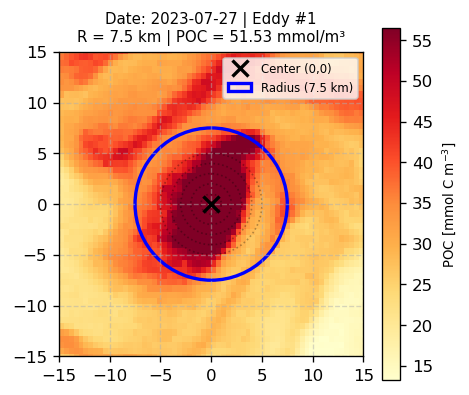

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


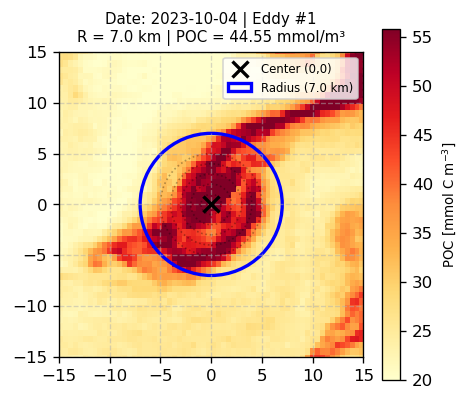

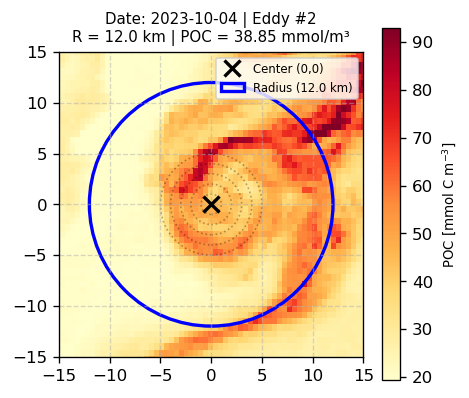

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


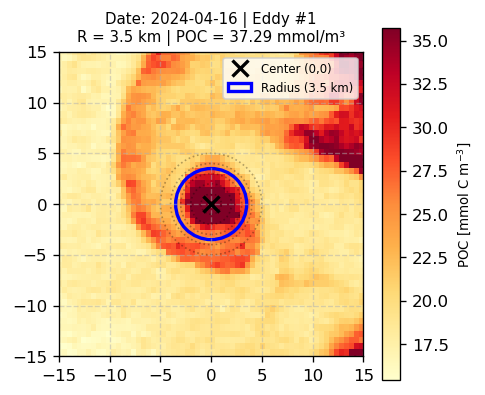

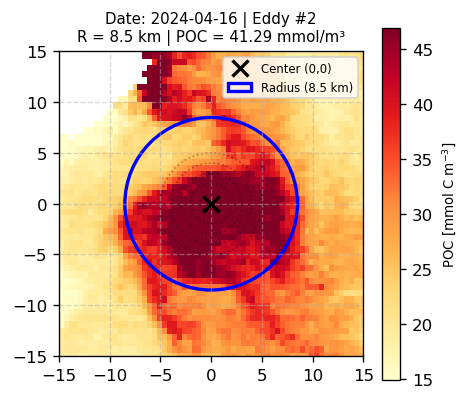

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


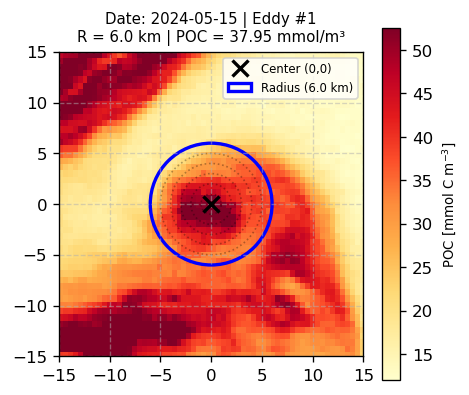

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


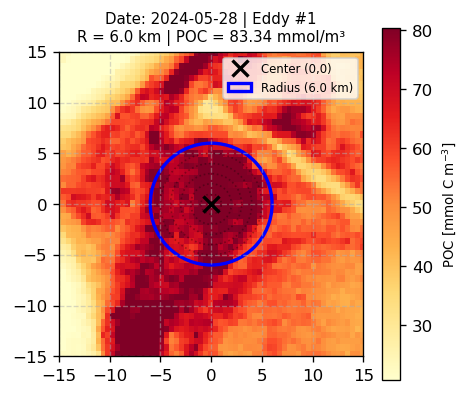

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


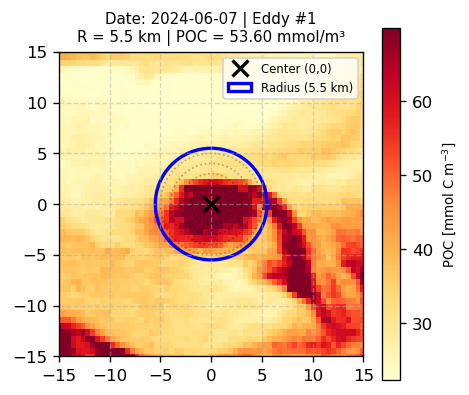

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


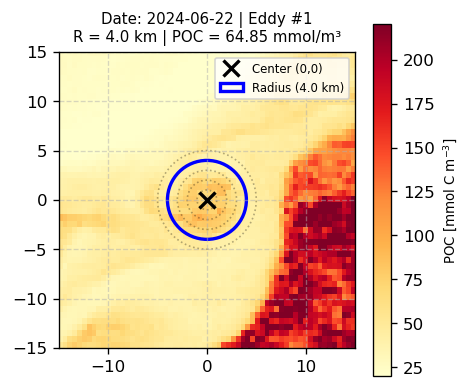

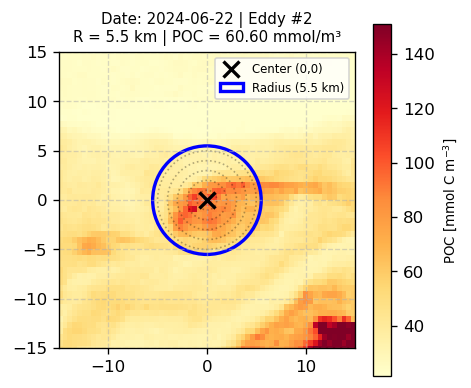

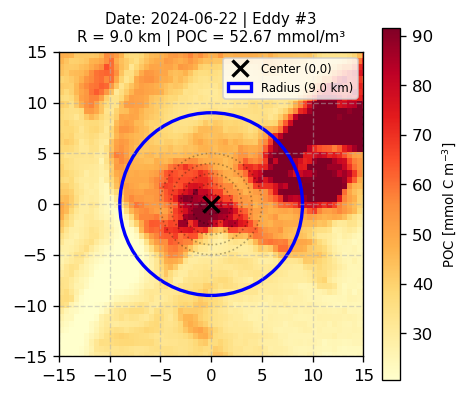

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:63: RuntimeWarning: Mean of empty slice
  c_peak = np.nanmean(poc_values[core_peak_mask])
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


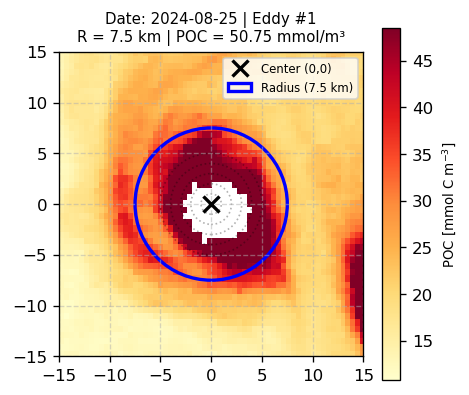

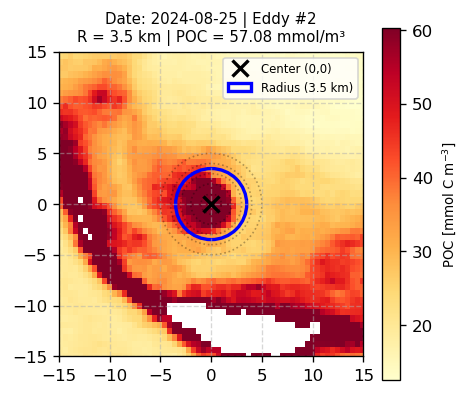

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


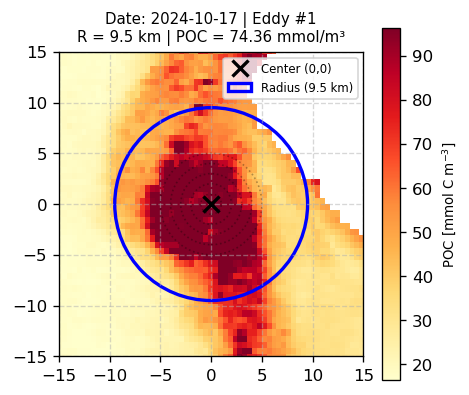

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


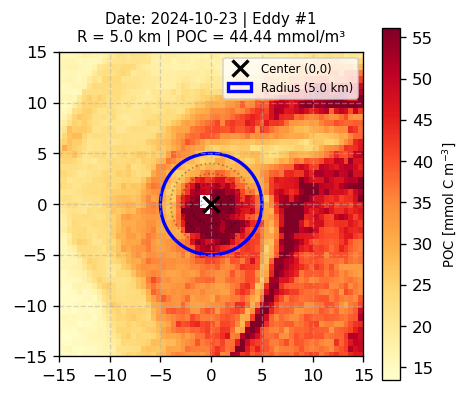

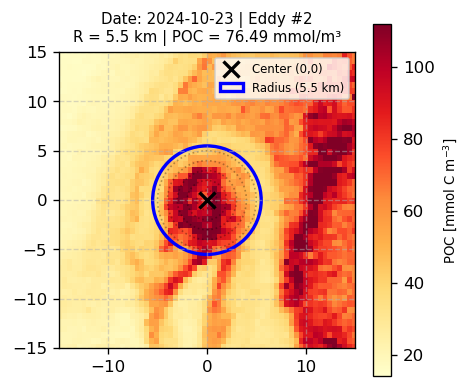

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


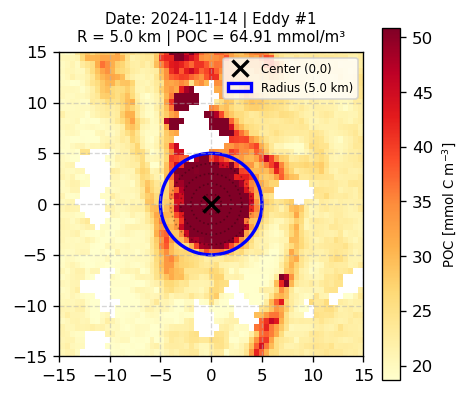

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


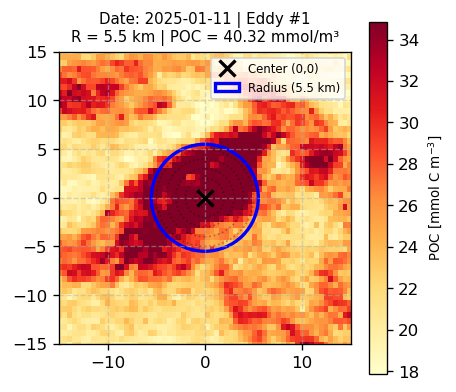

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


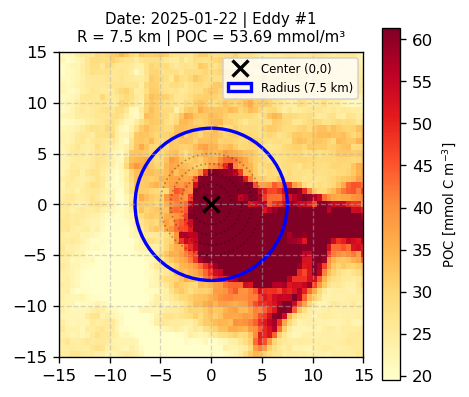

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


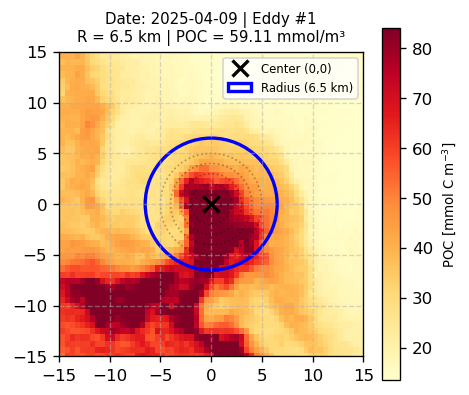

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


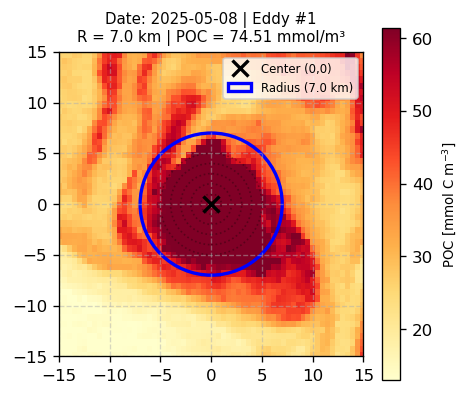

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


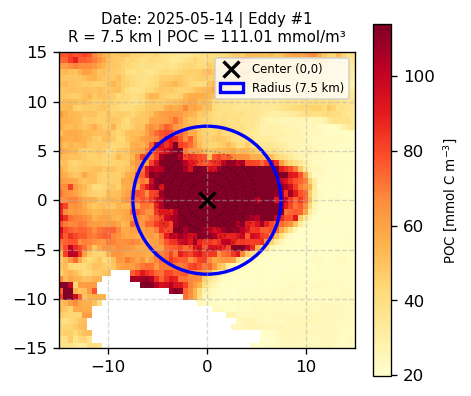

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


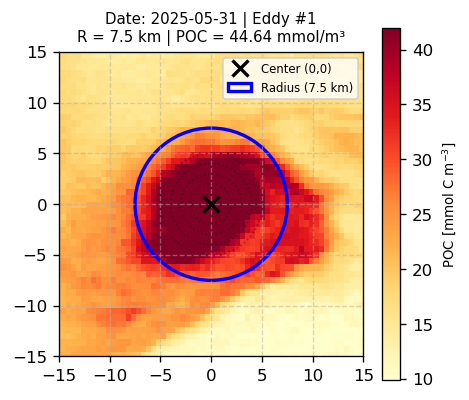

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


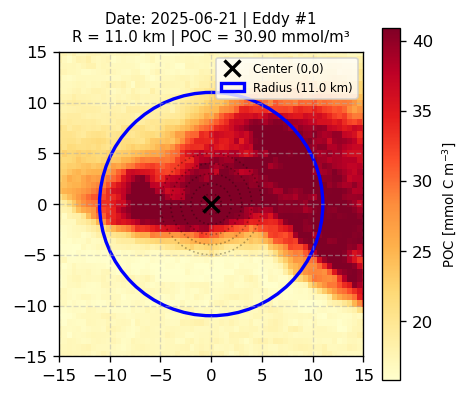

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


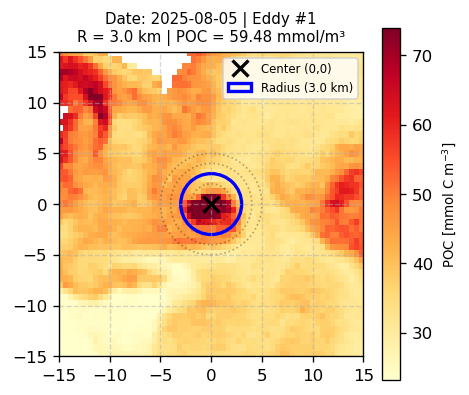

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


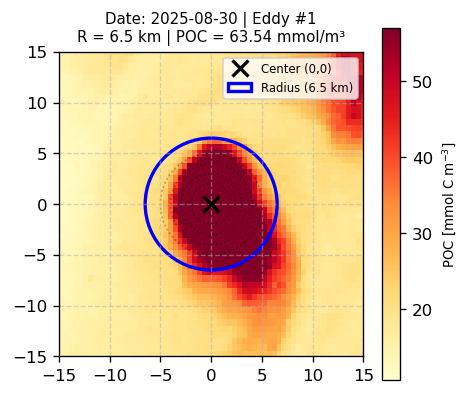

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_78486/991886204.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)  # [mmol C / m]


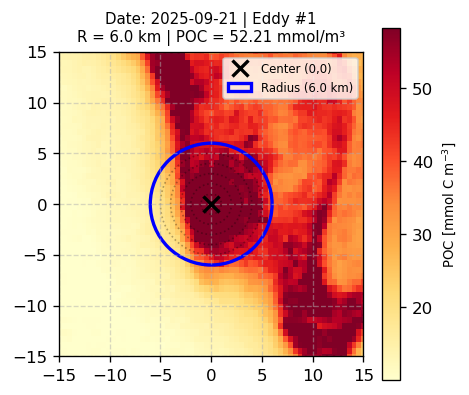

In [199]:
import ast
import os

# ------
# functions
# ------

def parse_coord(coord_str):
    """Safely converts a string '(Lon,Lat)' into a tuple of floats."""
    if pd.isna(coord_str) or not isinstance(coord_str, str):
        return None
    try:
        lon, lat = ast.literal_eval(coord_str.strip())
        # Enforce negative sign for West longitudes if missing
        if lon > 0:
            lon = -lon
        return float(lon), float(lat)
    except:
        return None

def chl_to_poc_mmol(chl_dataarray, mw_c=12.011):
    """Converts Chlorophyll-a [mg/m3] to POC [mmol C/m3] via Stramski et al."""
    poc_mg_m3 = 308.28 * (chl_dataarray ** 0.56)
    return poc_mg_m3 / mw_c

def compute_poc_inventory(radii_centers, ring_poc_means, detected_r_km, mld_m=50.0):
    """
    Computes total POC inventory inside R_eddy using radial integration:
    Inventory = MLD * 2 * pi * integral_0^R ( c(r) * r dr )
    
    Returns:
      inventory_GgC : Integrated core POC mass [Gg C] (1 Gg = 10^9 g = 10^3 Mg)
    """
    mask = radii_centers <= detected_r_km
    r_vals = radii_centers[mask]          # in km
    c_vals = ring_poc_means[mask]         # in mmol C / m3
    
    if len(r_vals) < 2:
        return 0.0
        
    r_m = r_vals * 1000.0                 # Convert km to meters
    integrand = c_vals * r_m              # [mmol C / m2]
    
    # Numerical integration using trapezoidal rule
    integral_val = np.trapz(integrand, r_m)  # [mmol C / m]
    
    # Total mmol C inside volume
    total_mmol_c = mld_m * 2.0 * np.pi * integral_val  # [mmol C]
    
    # Convert mmol C -> Grams -> Gigagrams (Gg C)
    # 1 mmol C = 12.011 mg C = 12.011e-12 Gg C
    total_g_c = (total_mmol_c * 12.011) / 1000.0       # [g C]
    inventory_GgC = total_g_c / 1e9                    # [Gg C]
    
    return inventory_GgC
    
def detect_eddy_radius_threshold(poc_values, dist_km, mld_m=50.0, max_r_km=12.0, decay_fraction=0.20):
    """
    Detects eddy radius and computes total integrated core POC inventory.
    """
    # 1. Core Peak & Background Baseline
    core_peak_mask = dist_km <= 1.0
    c_peak = np.nanmean(poc_values[core_peak_mask])
    
    bg_mask = (dist_km >= 10.0) & (dist_km <= 15.0)
    c_bg = np.nanmedian(poc_values[bg_mask]) if np.sum(bg_mask) > 0 else np.nanpercentile(poc_values, 10)
    
    if pd.isna(c_peak) or c_peak <= c_bg:
        c_peak = np.nanmax(poc_values[dist_km <= 3.0])
        
    c_cutoff = c_bg + decay_fraction * (c_peak - c_bg)
    
    # 2. Concentric Ring Profile
    dr = 0.5
    radii_bins = np.arange(0, max_r_km + dr, dr)
    detected_r_km = max_r_km
    
    ring_poc_means = []
    ring_centers = []
    consecutive_drops = 0
    
    for i in range(len(radii_bins) - 1):
        r_in, r_out = radii_bins[i], radii_bins[i+1]
        ring_mask = (dist_km >= r_in) & (dist_km < r_out)
        vals = poc_values[ring_mask]
        ring_mean = np.nanmean(vals) if np.sum(~np.isnan(vals)) > 0 else np.nan
        
        r_center = (r_in + r_out) / 2.0
        ring_poc_means.append(ring_mean)
        ring_centers.append(r_center)
        
        if (r_out > 1.5) and not np.isnan(ring_mean):
            if ring_mean < c_cutoff:
                consecutive_drops += 1
                if consecutive_drops >= 2:
                    detected_r_km = r_in
                    break
            else:
                consecutive_drops = 0

    ring_poc_means = np.array(ring_poc_means)
    ring_centers = np.array(ring_centers)
    
    # 3. Average Core Concentration
    core_mask = dist_km <= detected_r_km
    mean_core_poc = np.nanmean(poc_values[core_mask])
    
    # 4. Integrate Inventory (returns a single float in Gg C)
    inventory_GgC = compute_poc_inventory(
        radii_centers=ring_centers, 
        ring_poc_means=ring_poc_means, 
        detected_r_km=detected_r_km, 
        mld_m=mld_m
    )

    return detected_r_km, mean_core_poc, inventory_GgC

def plot_eddy_crop(poc_crop, dx, dy, lon_center, lat_center, date_str, ed_idx, 
                   detected_r_km, mean_core_poc, plot_type='relative'):
    """Handles spatial visualization and overlays radius cutoff and rings."""
    fig, ax = plt.subplots(figsize=(4, 4), dpi=120)
    poc_vals = np.squeeze(poc_crop.values)
    
    if plot_type == 'relative':
        mesh = ax.pcolormesh(
            dx, dy, poc_vals, cmap='YlOrRd', shading='nearest',
            vmin=np.nanpercentile(poc_vals, 5),
            vmax=np.nanpercentile(poc_vals, 95)
        )
        cbar = plt.colorbar(mesh, ax=ax, shrink=0.8)
        cbar.set_label(r'POC [mmol C m$^{-3}$]', fontsize=8)
        
        # Center marker
        ax.plot(0, 0, 'kx', markersize=10, markeredgewidth=2, label='Center (0,0)')
        
        # 1 km concentric guide rings
        for r_km in [1.0, 2.0, 3.0, 4.0, 5.0]:
            circle = plt.Circle((0, 0), r_km, color='black', fill=False, linestyle=':', alpha=0.3)
            ax.add_patch(circle)
            
        # Detected radius cutoff circle
        cutoff_circle = plt.Circle((0, 0), detected_r_km, color='blue', fill=False, 
                                   linewidth=2, label=f'Radius ({detected_r_km} km)')
        ax.add_patch(cutoff_circle)
        
        ax.set_xlim(-15, 15)
        ax.set_ylim(-15, 15)
        ax.set_aspect('equal')
        
    elif plot_type == 'latlon':
        p = poc_crop.plot(ax=ax, cmap='YlOrRd', robust=True, 
                          cbar_kwargs={'label': r'POC [mmol C m$^{-3}$]'})
        ax.plot(lon_center, lat_center, 'kx', markersize=10, markeredgewidth=2, label='Center')

    ax.set_title(f"Date: {date_str} | Eddy #{ed_idx}\nR = {detected_r_km} km | POC = {mean_core_poc:.2f} mmol/m³", fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=7)
    plt.tight_layout()
    plt.show()

# ---------
# main
# ---------

excel_path = "../count-submesoscale-eddies.xlsx"
olci_dir = "../olci_300m_downloads"

df = pd.read_excel(excel_path)
df.columns = ['Date', 'Count', 'Coord1', 'Coord2', 'Coord3'] + list(df.columns[5:])

eddy_summary = []

for idx, row in df.iterrows():
    date_dt = pd.to_datetime(row['Date'])
    if pd.isna(date_dt):
        continue
        
    date_str = date_dt.strftime('%Y-%m-%d')
    nc_file = os.path.join(olci_dir, f"OLCI_300m_CHL_{date_str}.nc")
    
    if not os.path.exists(nc_file):
        continue
        
    coords = [parse_coord(row['Coord1']), parse_coord(row['Coord2']), parse_coord(row['Coord3'])]
    coords = [c for c in coords if c is not None]
    
    if not coords:
        continue
        
    with xr.open_dataset(nc_file) as ds:
        chl = ds['CHL']
        
        for ed_idx, (lon_center, lat_center) in enumerate(coords, 1):
            delta = 0.25  # ~25 km window around core
            
            chl_crop = chl.sel(
                latitude=slice(lat_center - delta, lat_center + delta),
                longitude=slice(lon_center - delta, lon_center + delta)
            )
            
            if chl_crop.size == 0 or np.isnan(chl_crop.values).all():
                continue

            # 1. Convert CHL to POC
            poc_crop = chl_to_poc_mmol(chl_crop)

            # 2. Compute Relative Distance Grid (dx, dy)
            lons = chl_crop.longitude.values
            lats = chl_crop.latitude.values
            dy = (lats - lat_center) * 111.0
            dx = (lons - lon_center) * 111.0 * np.cos(np.radians(lat_center))
            
            lon_2d, lat_2d = np.meshgrid(dx, dy)
            dist_km = np.sqrt(lon_2d**2 + lat_2d**2)

            # 3. Detect Radius & Integrate Inventory
            detected_r_km, mean_core_poc, inventory_GgC = detect_eddy_radius_threshold(
                poc_values=np.squeeze(poc_crop.values), 
                dist_km=dist_km,
                mld_m=50.0  # Pass your MLD value here (e.g., 50m)
            )
            
            # 4. Save results for f-hat, C', and Inventory calculations
            eddy_summary.append({
                'Date': date_str,
                'Eddy_ID': ed_idx,
                'Lon': lon_center,
                'Lat': lat_center,
                'Radius_km': detected_r_km,
                'Core_POC_mmol_m3': mean_core_poc,
                'Inventory_GgC': inventory_GgC
            })

            # 5. Plot
            plot_eddy_crop(
                poc_crop=poc_crop, dx=dx, dy=dy, 
                lon_center=lon_center, lat_center=lat_center, 
                date_str=date_str, ed_idx=ed_idx, 
                detected_r_km=detected_r_km, mean_core_poc=mean_core_poc, 
                plot_type='relative'
            )

# Final output DataFrame containing detected radii and core POC
df_eddy_stats = pd.DataFrame(eddy_summary)
ds_eddy_stats = df_eddy_stats.to_xarray()



In [203]:
# first eddy is ours, let compare POC values
ratio_POC_Conc = ds_eddy_stats.isel(index=0)['Core_POC_mmol_m3'].values/M_eddy_Gg
ratio_POC_Inv  = ds_eddy_stats.isel(index=0)['Inventory_GgC'].values/C_bar_eddy

print(f'{ds_eddy_stats.isel(index=0)['Core_POC_mmol_m3'].values} vs {C_bar_eddy}')
print(f'{ds_eddy_stats.isel(index=0)['Inventory_GgC'].values} vs {M_eddy_Gg}')

# there is a different of factor 5, which we will use to compare eddies
print(ratio_POC_Conc,ratio_POC_Inv)

58.71135330200195 vs 17.17883393117603
7.631267546290383 vs 0.40513777474268103
144.91700592296496 0.4442250025155206


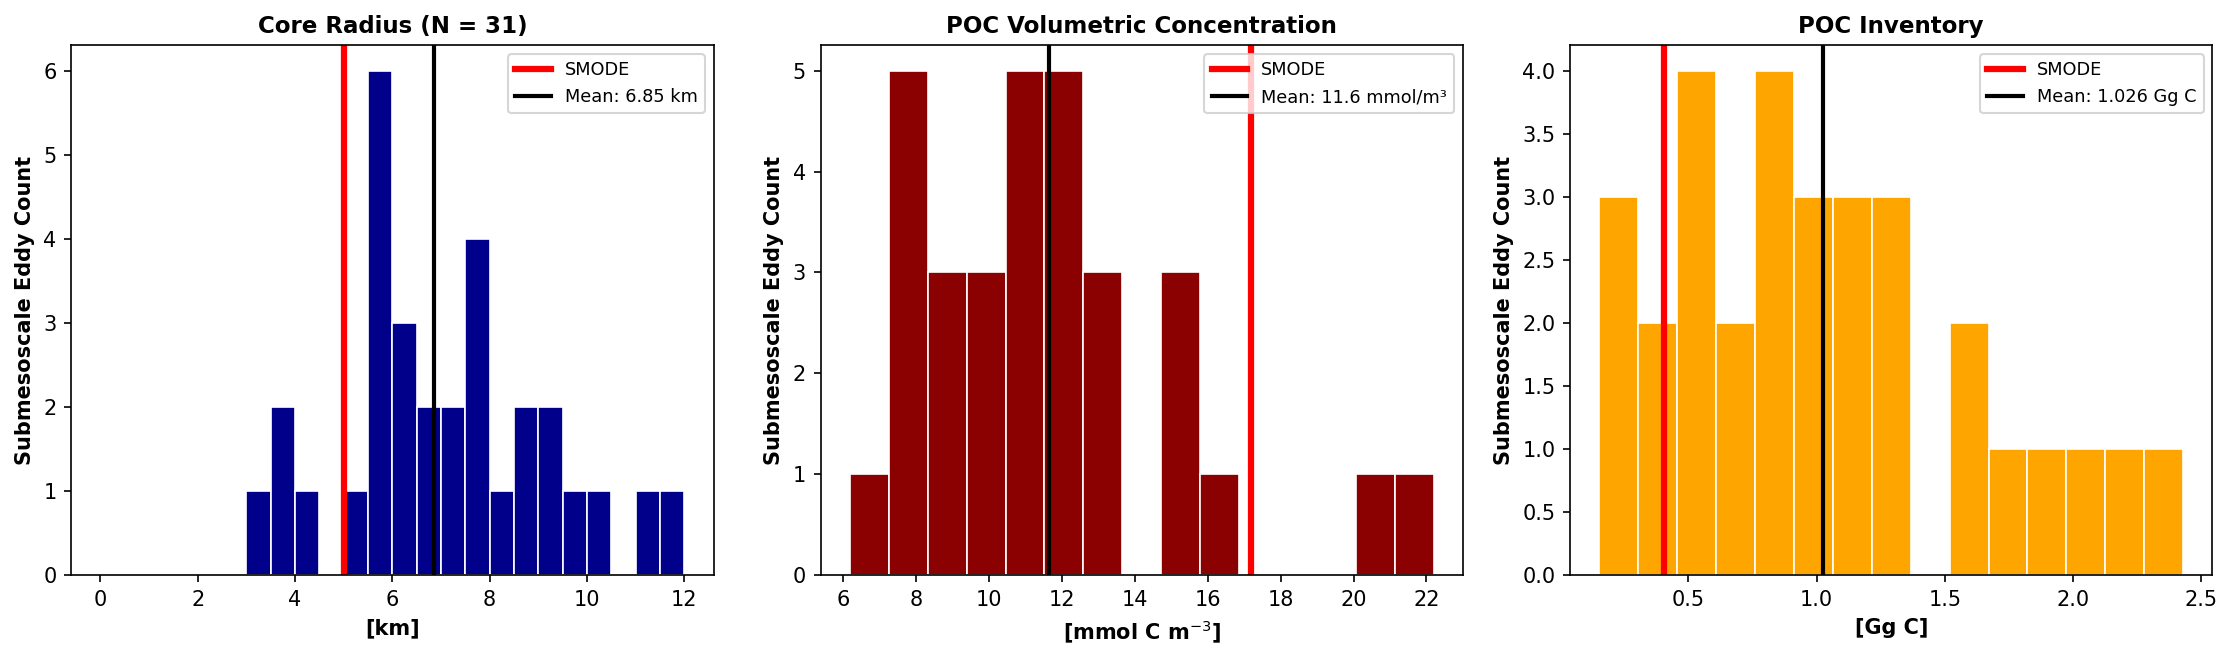

In [200]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load clean DataFrame
clean_df = pd.DataFrame(df_eddy_stats).dropna(
    subset=['Radius_km', 'Core_POC_mmol_m3', 'Inventory_GgC']
)

# Apply the in-situ calibration scaling factor (Divide by 5)
clean_df['Core_POC_mmol_m3'] = clean_df['Core_POC_mmol_m3'] / 5.0
clean_df['Inventory_GgC'] = clean_df['Inventory_GgC'] / 5.0

# Statistics
stats = {
    'r_mean': clean_df['Radius_km'].mean(),
    'r_median': clean_df['Radius_km'].median(),
    'c_mean': clean_df['Core_POC_mmol_m3'].mean(),
    'c_median': clean_df['Core_POC_mmol_m3'].median(),
    'inv_mean': clean_df['Inventory_GgC'].mean(),
    'inv_median': clean_df['Inventory_GgC'].median()
}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)

# PANEL 1: RADII DISTRIBUTION
ax1.hist(
    clean_df['Radius_km'], 
    bins=np.arange(0, clean_df['Radius_km'].max() + 0.5, 0.5),
    color='darkblue', edgecolor='w', alpha=1, linewidth=0.8
)
ax1.axvline(R_eddy/1e3, color='r', linewidth=3, label='SMODE') # ***

ax1.axvline(stats['r_mean'], color='k', linestyle='-', lw=2, label=f"Mean: {stats['r_mean']:.2f} km")
ax1.set_xlabel(r'[km]', fontweight='bold', fontsize=10)
ax1.set_ylabel('Submesoscale Eddy Count', fontweight='bold', fontsize=10)
ax1.set_title(f'Core Radius (N = {len(clean_df)})', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', fontsize=8.5)

# PANEL 2: VOLUMETRIC CONCENTRATION DISTRIBUTION
ax2.hist(
    clean_df['Core_POC_mmol_m3'], 
    bins=15,
    color='darkred', edgecolor='w', alpha=1, linewidth=0.8
)
ax2.axvline(C_bar_eddy, color='r', linewidth=3, label='SMODE') # ***

ax2.axvline(stats['c_mean'], color='k', linestyle='-', lw=2, label=f"Mean: {stats['c_mean']:.1f} mmol/m³")
ax2.set_xlabel(r'[mmol C m$^{-3}$]', fontweight='bold', fontsize=10)
ax2.set_ylabel('Submesoscale Eddy Count', fontweight='bold', fontsize=10)
ax2.set_title(r'POC Volumetric Concentration', fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', fontsize=8.5)

# PANEL 3: POC INVENTORY (Gg C) DISTRIBUTION
ax3.hist(
    clean_df['Inventory_GgC'], 
    bins=15, 
    color='orange', edgecolor='w', alpha=1, linewidth=0.8
)
ax3.axvline(M_eddy_Gg, color='r', linewidth=3, label='SMODE') # ***
ax3.axvline(stats['inv_mean'], color='k', linestyle='-', lw=2, label=f"Mean: {stats['inv_mean']:.3f} Gg C")
ax3.set_xlabel(r'[Gg C]', fontweight='bold', fontsize=10)
ax3.set_ylabel('Submesoscale Eddy Count', fontweight='bold', fontsize=10)
ax3.set_title(r'POC Inventory', fontsize=11, fontweight='bold')
ax3.legend(loc='upper right', fontsize=8.5)


plt.tight_layout()
plt.show()

In [30]:
# for each snapshot, measure average POC along the line, and cloud along the line, and eddy space along the line

'2023-08-26'

In [ ]:
F_prime_per_sec = u_eddy * C_bar_prime * f_hat # [mmol C m-2 s-1]

F_prime_per_day = F_prime_per_sec * 86400 # [mmol C m-2 d-1]

In [ ]:
# integrated lateral from
F_prime_per_day * MLD

$$
L_{124\degree W} \times MLD
$$